In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='darkgrid')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving supernova_dataset.csv to supernova_dataset.csv


In [ ]:
df = pd.read_csv("supernova_dataset.csv")
print(f'✅ Dataset loaded! Shape: {df.shape}')
print(f'   Rows: {df.shape[0]} | Columns: {df.shape[1]}')

✅ Dataset loaded! Shape: (9564, 26)
   Rows: 9564 | Columns: 26


In [ ]:
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
0,10797460,CONFIRMED,9.488036,2.95750,615.8,0.146,35.8,142.0,0.022344,2.26,...,123.0,-123.0,0.068,-0.243,0.15,-0.15,0.13150,-0.08685,0.465,-0.114
1,10797460,CONFIRMED,54.418383,4.50700,874.8,0.586,25.8,25.0,0.027954,2.83,...,123.0,-123.0,0.068,-0.243,0.15,-0.15,0.13150,-0.08685,0.465,-0.114
2,10811496,CANDIDATE,19.899140,1.78220,10829.0,0.969,76.3,56.0,0.154046,14.60,...,158.0,-171.0,0.044,-0.176,0.26,-0.26,0.10375,-0.11465,0.237,-0.078
3,10848459,FALSE POSITIVE,1.736952,2.40641,8079.2,1.276,505.6,621.0,0.387394,33.46,...,157.0,-144.0,0.053,-0.223,0.30,-0.26,0.09995,-0.07165,0.364,-0.068
4,10854555,CONFIRMED,2.525592,1.65450,603.3,0.701,40.9,515.0,0.024064,2.75,...,151.0,-207.0,0.070,-0.222,0.17,-0.29,0.19050,-0.13700,0.442,-0.133


In [ ]:
print('=== Column Info ===')
df.info()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepid             9564 non-null   int64  
 1   koi_disposition   9564 non-null   object 
 2   koi_period        9564 non-null   float64
 3   koi_duration      9564 non-null   float64
 4   koi_depth         9201 non-null   float64
 5   koi_impact        9201 non-null   float64
 6   koi_model_snr     9201 non-null   float64
 7   koi_num_transits  8422 non-null   float64
 8   koi_ror           9201 non-null   float64
 9   koi_prad          9201 non-null   float64
 10  st_teff           9564 non-null   float64
 11  st_logg           9564 non-null   float64
 12  st_met            9564 non-null   float64
 13  st_mass           9455 non-null   float64
 14  st_radius         9564 non-null   float64
 15  st_dens           9455 non-null   float64
 16  teff_err1         9455

In [ ]:
print('=== Basic Statistics ===')
df.describe()

=== Basic Statistics ===


,kepid,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,st_teff,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
count,9.564000e+03,9564.000000,9564.000000,9.201000e+03,9201.000000,9201.000000,8422.000000,9201.000000,9201.000000,9564.000000,...,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000
mean,7.690628e+06,75.671358,5.621606,2.379134e+04,0.735105,259.895001,385.006768,0.283646,102.891778,5735.384097,...,143.579799,-157.755050,0.112668,-0.173389,0.216397,-0.241631,0.135913,-0.138698,0.426745,-0.352531
std,2.653459e+06,1334.744046,6.471554,8.224268e+04,3.348832,795.806615,545.756200,3.306558,3077.639126,813.065666,...,42.852680,62.775082,0.104687,0.080668,0.070713,0.077279,0.085605,0.168463,0.887806,1.701414
min,7.574500e+05,0.241843,0.052000,0.000000e+00,0.000000,0.000000,0.000000,0.001289,0.080000,2661.000000,...,0.000000,-1473.000000,0.000000,-0.748000,0.000000,-0.750000,0.000000,-2.579000,0.000000,-101.136000
25%,5.556034e+06,2.733684,2.437750,1.599000e+02,0.197000,12.000000,41.000000,0.012341,1.400000,5325.000000,...,109.000000,-190.000000,0.045000,-0.224000,0.150000,-0.300000,0.081925,-0.138000,0.196000,-0.270000
50%,7.906892e+06,9.752831,3.792600,4.211000e+02,0.537000,23.000000,143.000000,0.021076,2.390000,5783.000000,...,153.000000,-149.000000,0.074000,-0.193000,0.220000,-0.260000,0.115500,-0.098000,0.356000,-0.114000
75%,9.873066e+06,40.715178,6.276500,1.473400e+03,0.889000,78.000000,469.000000,0.095348,14.930000,6143.000000,...,168.000000,-115.000000,0.153000,-0.122000,0.280000,-0.150000,0.177500,-0.064000,0.453000,-0.071000
max,1.293514e+07,129995.778400,138.540000,1.541400e+06,100.806000,9054.700000,2664.000000,99.870651,200346.000000,15896.000000,...,676.000000,0.000000,1.184000,0.000000,0.450000,0.000000,1.493000,0.000000,25.956000,0.000000


In [ ]:
# Value counts
print('=== koi_disposition Value Counts ===')
print(df['koi_disposition'].value_counts())
print()
print('=== Percentage Distribution ===')
print(df['koi_disposition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== koi_disposition Value Counts ===
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

=== Percentage Distribution ===
koi_disposition
FALSE POSITIVE     50.6%
CONFIRMED         28.71%
CANDIDATE         20.69%
Name: proportion, dtype: object


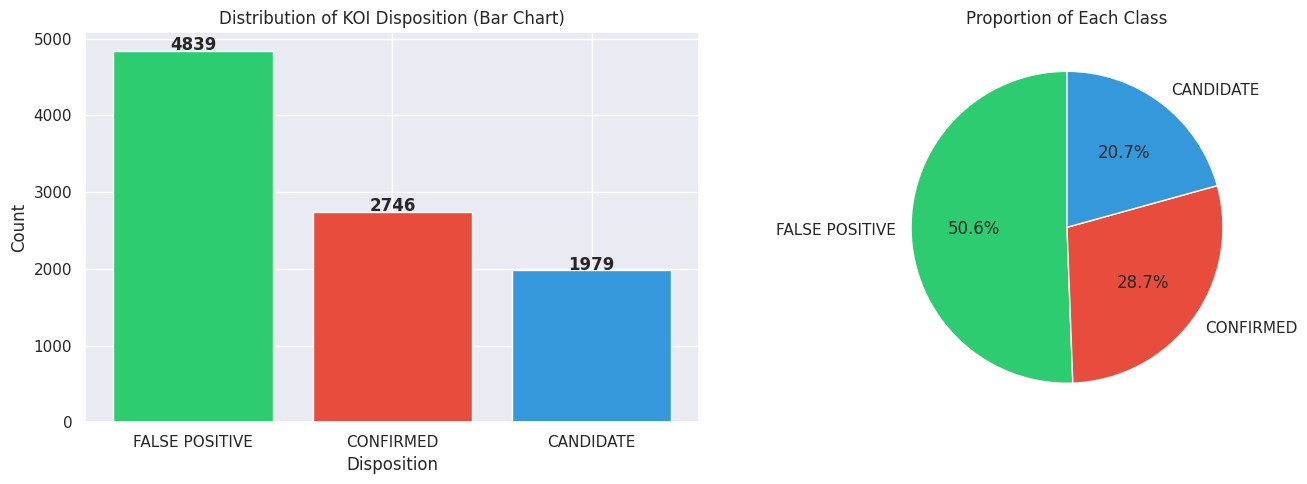

💡 NOTE: CANDIDATE rows will be dropped for Task A (Classification)


In [ ]:
# Plot: Distribution of classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['koi_disposition'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribution of KOI Disposition (Bar Chart)')
axes[0].set_xlabel('Disposition')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proportion of Each Class')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 NOTE: CANDIDATE rows will be dropped for Task A (Classification)')

In [ ]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df_filtered = missing_df[missing_df['Missing Count'] > 0]
print(f'Columns with missing values: {len(missing_df_filtered)}')
print(missing_df_filtered)

Columns with missing values: 18
                  Missing Count  Missing %
koi_num_transits           1142      11.94
koi_impact                  363       3.80
koi_ror                     363       3.80
koi_prad                    363       3.80
koi_model_snr               363       3.80
koi_depth                   363       3.80
st_dens                     109       1.14
teff_err1                   109       1.14
teff_err2                   109       1.14
st_mass                     109       1.14
mass_err1                   109       1.14
mass_err2                   109       1.14
radius_err1                 109       1.14
radius_err2                 109       1.14
feh_err2                    109       1.14
feh_err1                    109       1.14
logg_err2                   109       1.14
logg_err1                   109       1.14


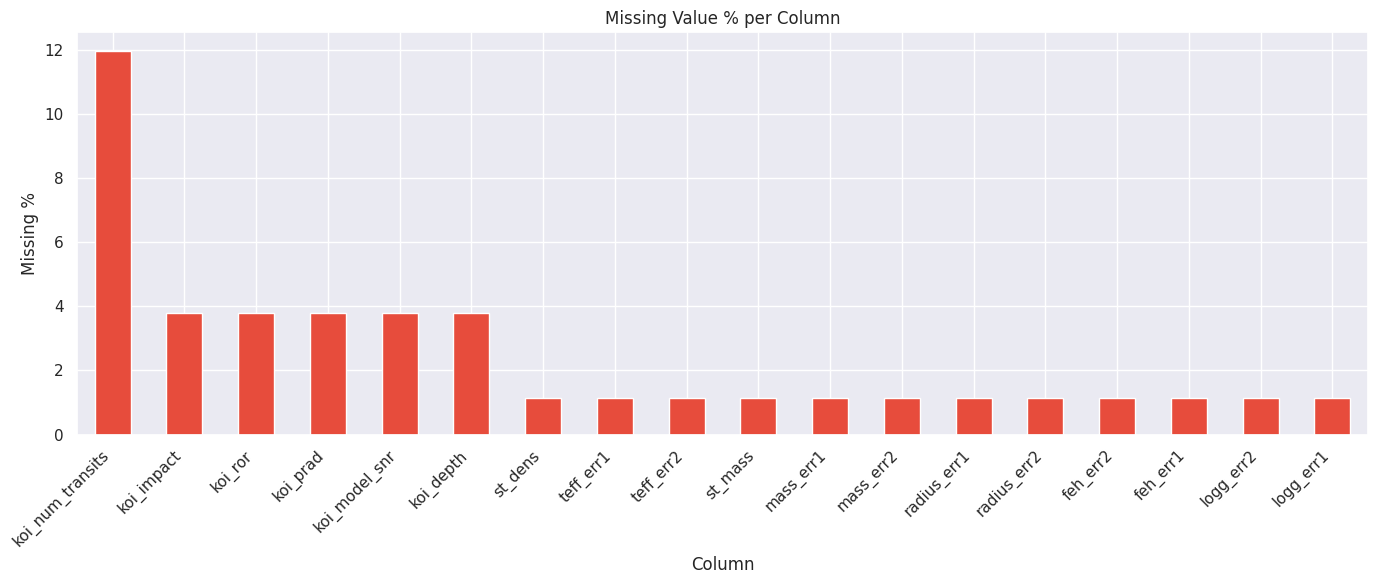

In [ ]:
# Visual heatmap of missing values
if len(missing_df_filtered) > 0:
    plt.figure(figsize=(14, 6))
    missing_df_filtered['Missing %'].plot(kind='bar', color='#e74c3c')
    plt.title('Missing Value % per Column')
    plt.xlabel('Column')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('✅ No missing values found!')

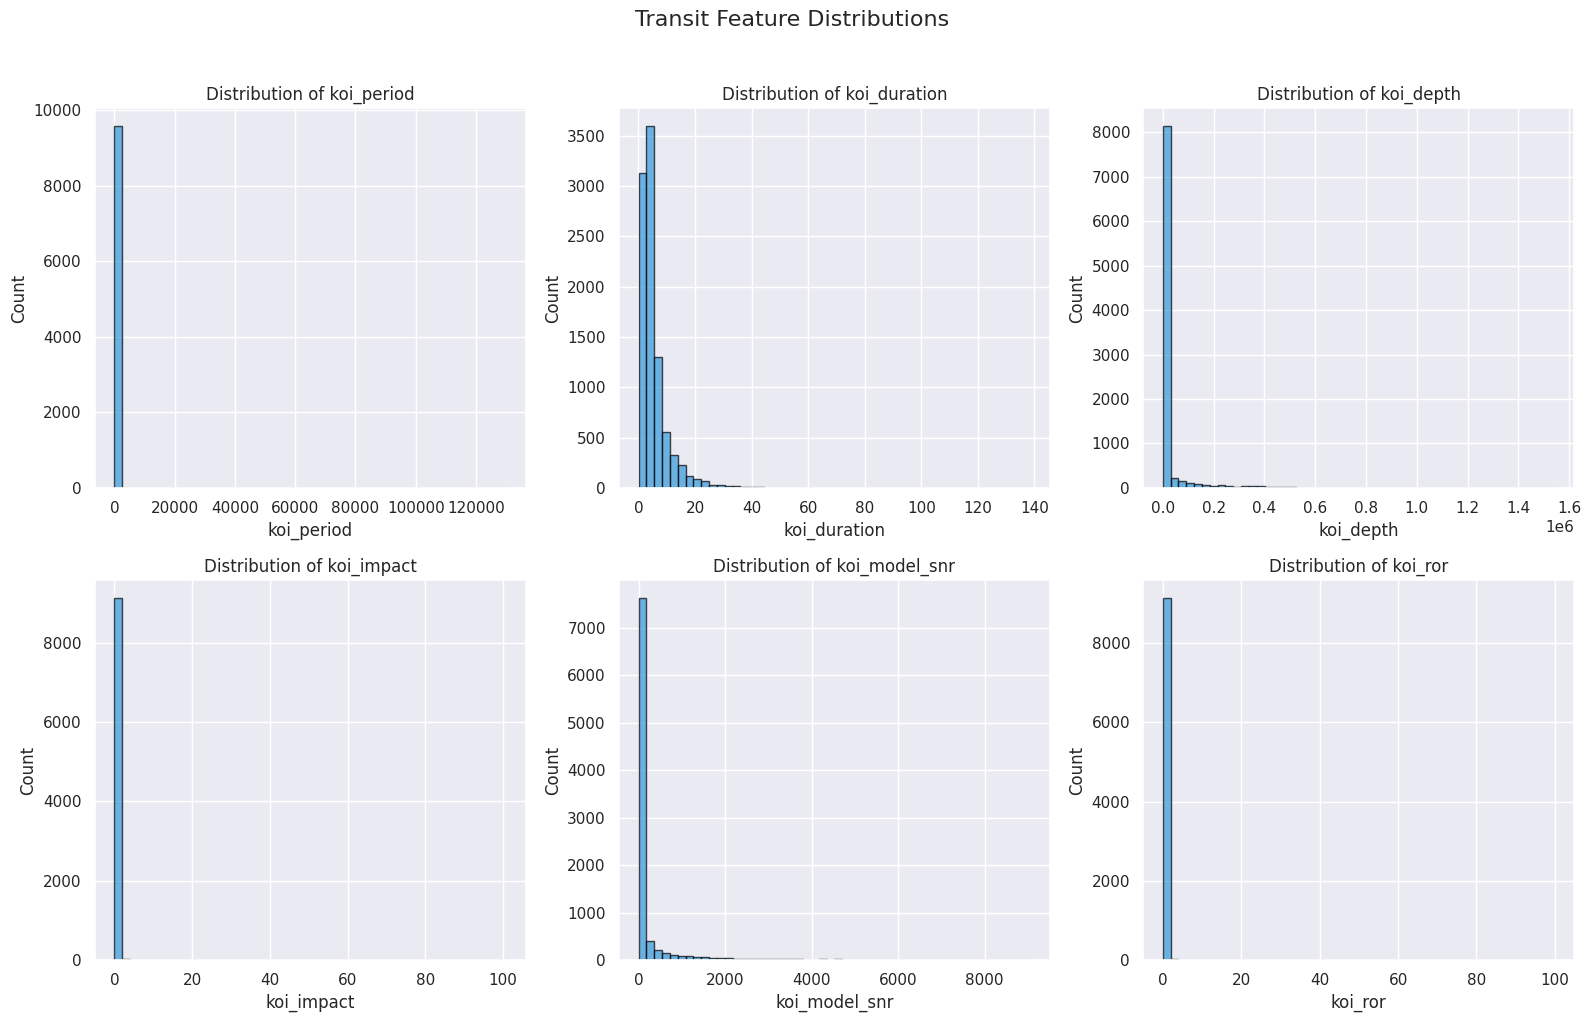

In [ ]:
transit_features = [
    'koi_period',
    'koi_duration',
    'koi_depth',
    'koi_impact',
    'koi_model_snr',
    'koi_ror'
]

# Only keep features that exist in the dataset
transit_features = [f for f in transit_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(transit_features):
    df[feature].dropna().hist(bins=50, ax=axes[i], color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

# Hide empty subplots
for j in range(len(transit_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Transit Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('transit_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

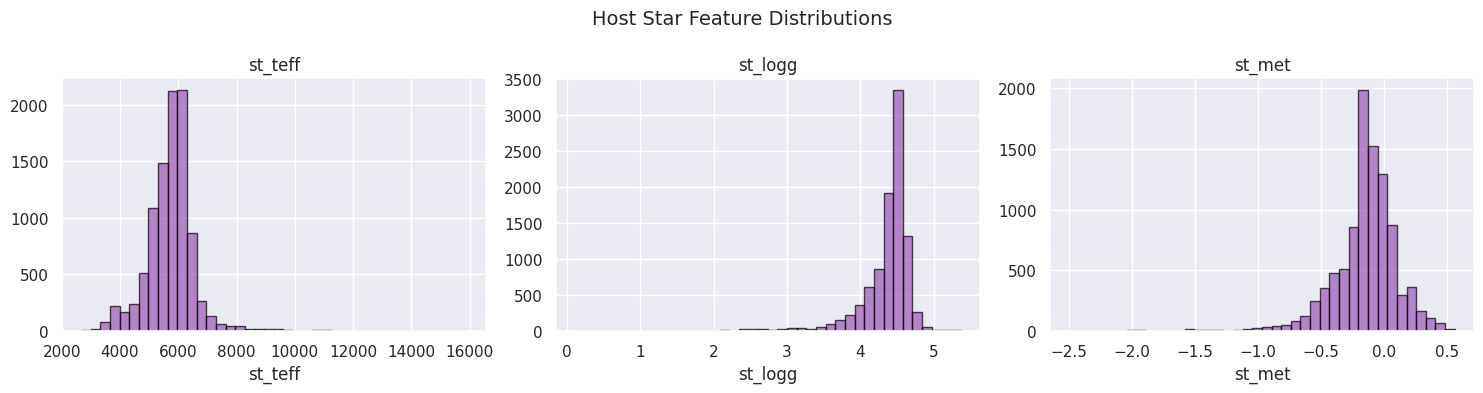

In [ ]:
# Star features distribution
stellar_features = ['st_teff', 'st_logg', 'st_met']
stellar_features = [f for f in stellar_features if f in df.columns]

fig, axes = plt.subplots(1, len(stellar_features), figsize=(15, 4))
if len(stellar_features) == 1:
    axes = [axes]

for i, feature in enumerate(stellar_features):
    df[feature].dropna().hist(bins=40, ax=axes[i], color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel(feature)

plt.suptitle('Host Star Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('stellar_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

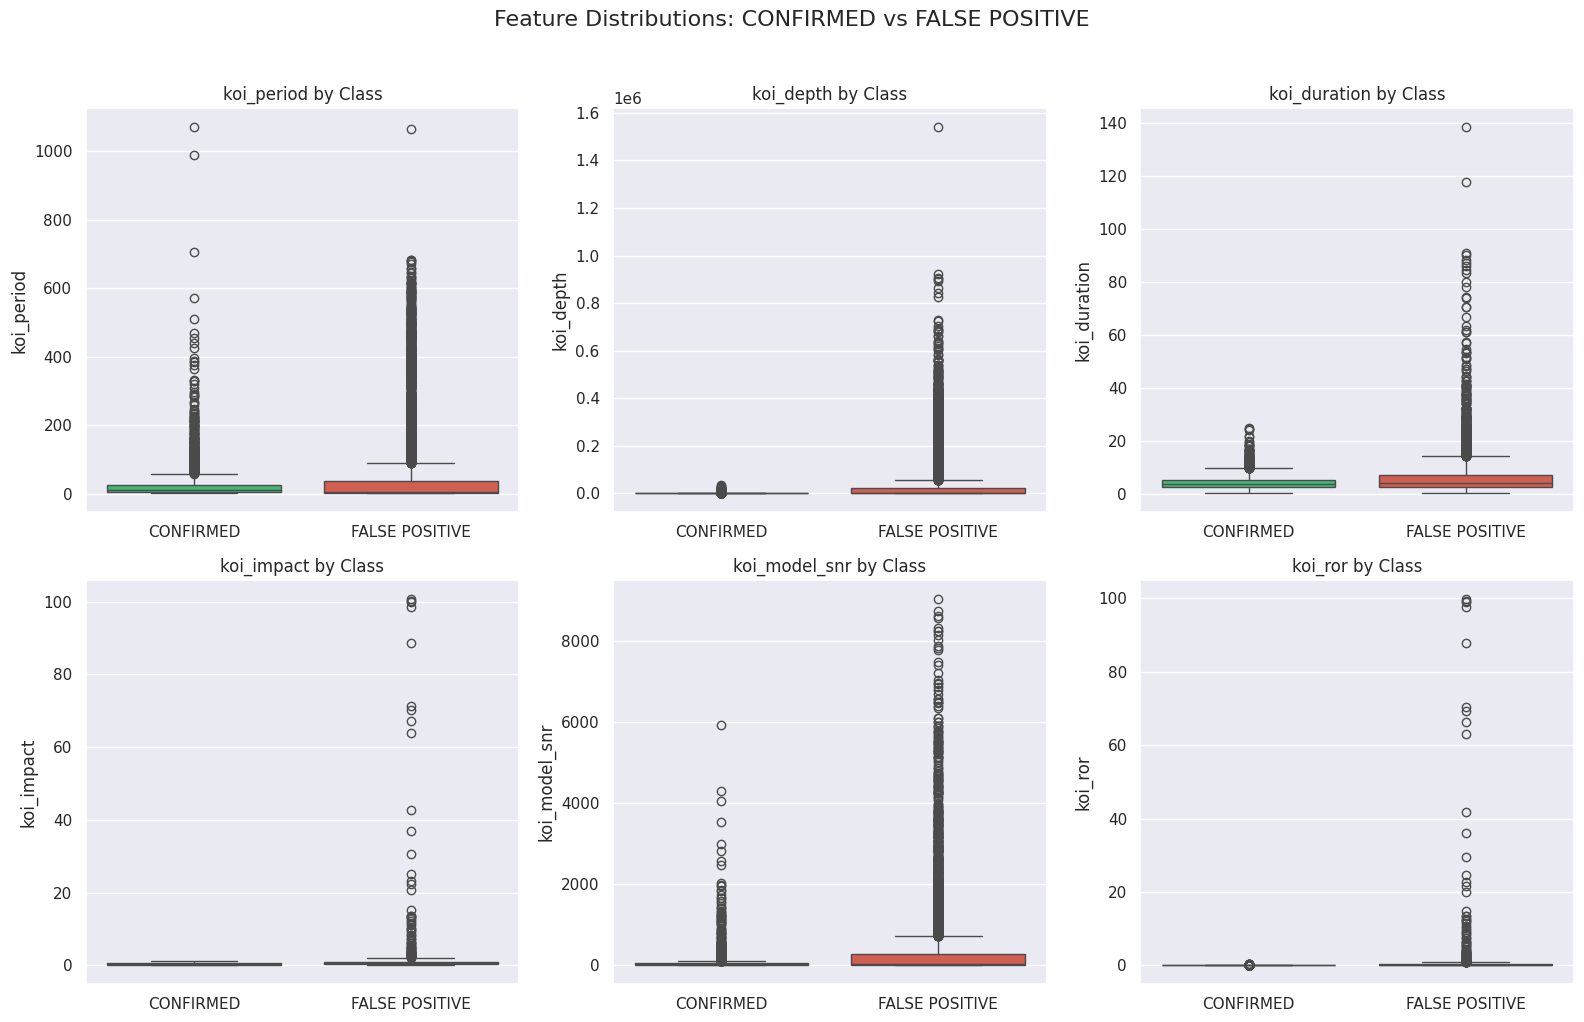

💡 Features that show clear separation between classes are the most useful for Task A!


In [ ]:
# Compare features between CONFIRMED and FALSE POSITIVE
# Filter only the two main classes
df_two_class = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

features_to_compare = [
    'koi_period', 'koi_depth', 'koi_duration',
    'koi_impact', 'koi_model_snr', 'koi_ror'
]
features_to_compare = [f for f in features_to_compare if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

palette = {'CONFIRMED': '#2ecc71', 'FALSE POSITIVE': '#e74c3c'}

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        data=df_two_class,
        x='koi_disposition',
        y=feature,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Class')
    axes[i].set_xlabel('')

for j in range(len(features_to_compare), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: CONFIRMED vs FALSE POSITIVE', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Features that show clear separation between classes are the most useful for Task A!')

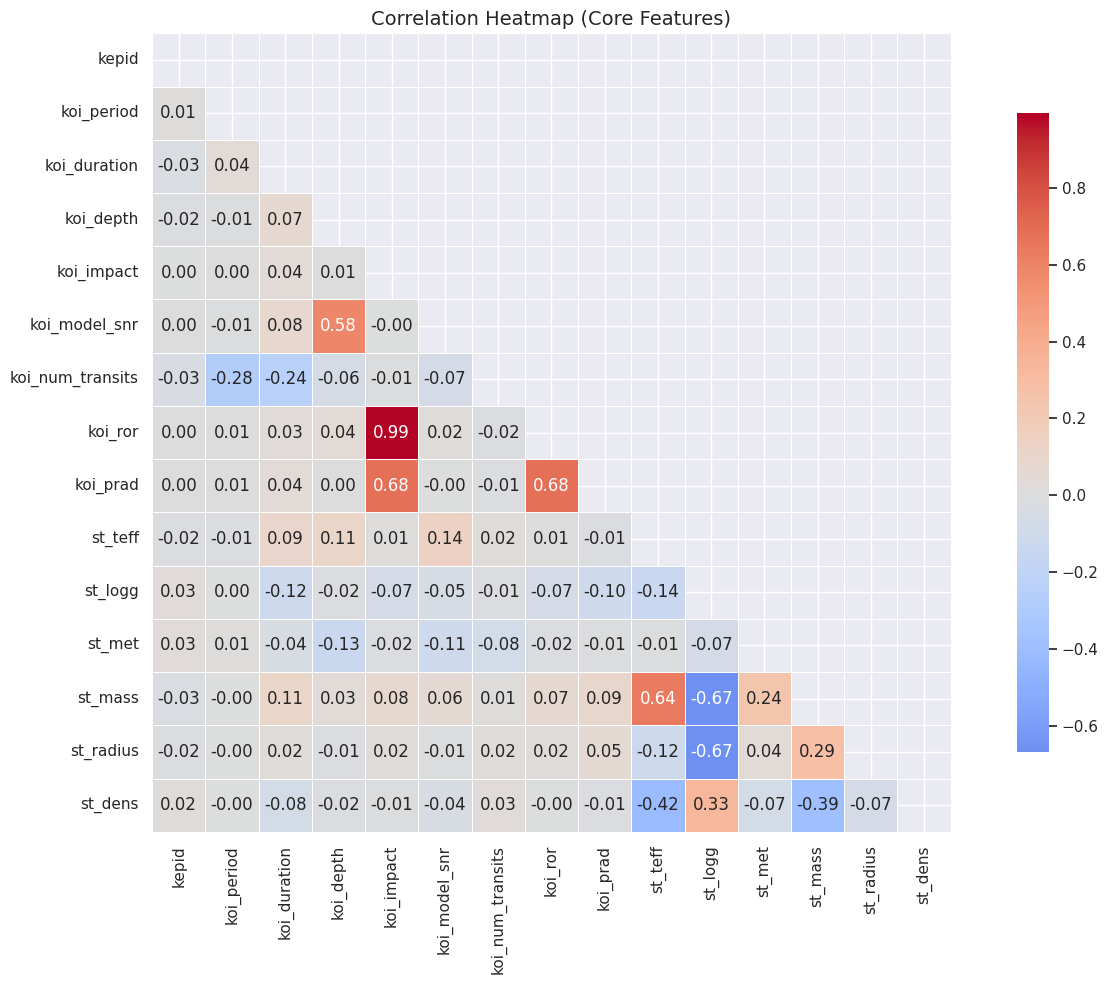

💡 High correlation (>0.8) between two features = consider dropping one to avoid redundancy!


In [ ]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove error/uncertainty columns for clarity
core_cols = [c for c in numeric_cols if 'err' not in c.lower()]

corr_matrix = df[core_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (Core Features)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 High correlation (>0.8) between two features = consider dropping one to avoid redundancy!')

CONFIRMED exoplanets: 2746


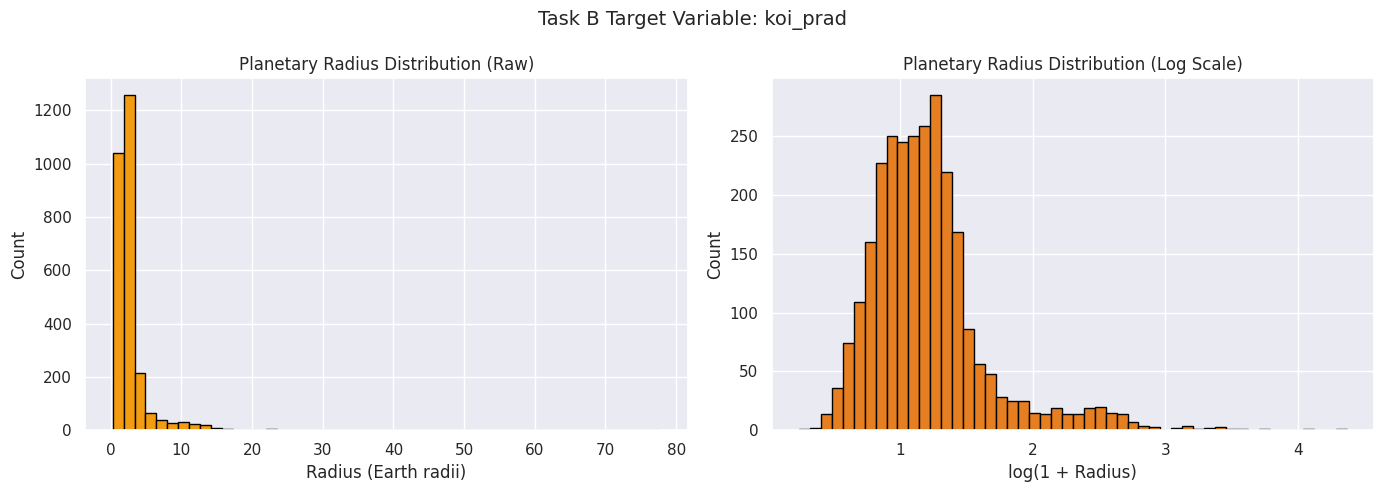


Planetary Radius Stats:
count    2744.000000
mean        2.857372
std         3.400970
min         0.270000
25%         1.510000
50%         2.155000
75%         2.920000
max        77.760000
Name: koi_prad, dtype: float64

💡 If distribution is right-skewed, use log(koi_prad) as your regression target!


In [ ]:
# Only look at CONFIRMED planets for regression task
df_confirmed = df[df['koi_disposition'] == 'CONFIRMED'].copy()
print(f'CONFIRMED exoplanets: {len(df_confirmed)}')

if 'koi_prad' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw distribution
    df_confirmed['koi_prad'].dropna().hist(bins=50, ax=axes[0], color='#f39c12', edgecolor='black')
    axes[0].set_title('Planetary Radius Distribution (Raw)')
    axes[0].set_xlabel('Radius (Earth radii)')
    axes[0].set_ylabel('Count')

    # Log-transformed distribution (helps with skewed data)
    log_prad = np.log1p(df_confirmed['koi_prad'].dropna())
    log_prad.hist(bins=50, ax=axes[1], color='#e67e22', edgecolor='black')
    axes[1].set_title('Planetary Radius Distribution (Log Scale)')
    axes[1].set_xlabel('log(1 + Radius)')
    axes[1].set_ylabel('Count')

    plt.suptitle('Task B Target Variable: koi_prad', fontsize=14)
    plt.tight_layout()
    plt.savefig('prad_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nPlanetary Radius Stats:")
    print(df_confirmed['koi_prad'].describe())
    print(f"\n💡 If distribution is right-skewed, use log(koi_prad) as your regression target!")

In [ ]:
# ============================================================
# FEATURE GROUPS
# ============================================================

# ID column - always drop
ID_COLS = ['kepid']

# Target columns
TARGET_CLASS = 'koi_disposition'   # Task A
TARGET_REG   = 'koi_prad'          # Task B

# Core transit features (most useful for ML)
TRANSIT_FEATURES = [
    'koi_period',
    'koi_duration',
    'koi_depth',
    'koi_impact',
    'koi_model_snr',
    'koi_num_transits',
    'koi_ror'
]

# Host star features
STELLAR_FEATURES = ['teff', 'logg', 'feh']

# Error columns (optional — we'll engineer one avg uncertainty per feature)
ERROR_COLS = [c for c in df.columns if 'err' in c.lower()]

# Filter to only existing columns
TRANSIT_FEATURES = [f for f in TRANSIT_FEATURES if f in df.columns]
STELLAR_FEATURES = [f for f in STELLAR_FEATURES if f in df.columns]

ALL_FEATURES = TRANSIT_FEATURES + STELLAR_FEATURES

print('Transit Features:', TRANSIT_FEATURES)
print('Stellar Features:', STELLAR_FEATURES)
print('Error Columns:', ERROR_COLS)
print(f'\nTotal features for ML: {len(ALL_FEATURES)}')

Transit Features: ['koi_period', 'koi_duration', 'koi_depth', 'koi_impact', 'koi_model_snr', 'koi_num_transits', 'koi_ror']
Stellar Features: []
Error Columns: ['teff_err1', 'teff_err2', 'logg_err1', 'logg_err2', 'feh_err1', 'feh_err2', 'mass_err1', 'mass_err2', 'radius_err1', 'radius_err2']

Total features for ML: 7


In [ ]:
# ============================================================
# FEATURE ENGINEERING
# Create average uncertainty features from err1 and err2 columns
# ============================================================

df_processed = df.copy()

# Map of base feature → its error columns
error_pairs = {
    'teff': ('teff_err1', 'teff_err2'),
    'logg': ('logg_err1', 'logg_err2'),
    'feh':  ('feh_err1',  'feh_err2'),
}

for base, (err1, err2) in error_pairs.items():
    if err1 in df.columns and err2 in df.columns:
        # Average absolute uncertainty
        df_processed[f'{base}_uncertainty'] = (
            df_processed[err1].abs() + df_processed[err2].abs()
        ) / 2
        print(f'✅ Created: {base}_uncertainty')

# Add ratio: transit depth / orbital period (signal strength per orbit)
if 'koi_depth' in df.columns and 'koi_period' in df.columns:
    df_processed['depth_per_period'] = df_processed['koi_depth'] / (df_processed['koi_period'] + 1e-9)
    print('✅ Created: depth_per_period')

# SNR per transit
if 'koi_model_snr' in df.columns and 'koi_num_transits' in df.columns:
    df_processed['snr_per_transit'] = df_processed['koi_model_snr'] / (df_processed['koi_num_transits'] + 1e-9)
    print('✅ Created: snr_per_transit')

print('\n✅ Feature engineering complete!')

✅ Created: teff_uncertainty
✅ Created: logg_uncertainty
✅ Created: feh_uncertainty
✅ Created: depth_per_period
✅ Created: snr_per_transit

✅ Feature engineering complete!


In [ ]:
# ============================================================
# TASK A PREPARATION
# Goal: CONFIRMED (1) vs FALSE POSITIVE (0)
# ============================================================

# Step 1: Drop CANDIDATE rows (ambiguous labels)
df_taskA = df_processed[df_processed[TARGET_CLASS].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
print(f'Rows after dropping CANDIDATE: {len(df_taskA)}')

# Step 2: Encode labels — CONFIRMED=1, FALSE POSITIVE=0
df_taskA['label'] = df_taskA[TARGET_CLASS].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})
print(f"\nLabel Distribution:\n{df_taskA['label'].value_counts()}")

# Step 3: Update feature list with engineered features
engineered_features = [c for c in df_processed.columns if
    c.endswith('_uncertainty') or c in ['depth_per_period', 'snr_per_transit']]

FEATURES_A = ALL_FEATURES + engineered_features
FEATURES_A = [f for f in FEATURES_A if f in df_taskA.columns]

# Remove target variable from features just in case
if TARGET_REG in FEATURES_A:
    FEATURES_A.remove(TARGET_REG)

print(f'\nFeatures for Task A ({len(FEATURES_A)}): {FEATURES_A}')

Rows after dropping CANDIDATE: 7585

Label Distribution:
label
0    4839
1    2746
Name: count, dtype: int64

Features for Task A (12): ['koi_period', 'koi_duration', 'koi_depth', 'koi_impact', 'koi_model_snr', 'koi_num_transits', 'koi_ror', 'teff_uncertainty', 'logg_uncertainty', 'feh_uncertainty', 'depth_per_period', 'snr_per_transit']


In [ ]:
# Step 4: Handle missing values with median imputation
imputer_A = SimpleImputer(strategy='median')
X_A = imputer_A.fit_transform(df_taskA[FEATURES_A])
X_A = pd.DataFrame(X_A, columns=FEATURES_A)
y_A = df_taskA['label'].values

# Step 5: Scale features (StandardScaler)
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)
X_A_scaled = pd.DataFrame(X_A_scaled, columns=FEATURES_A)

# Step 6: Train-test split
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A_scaled, y_A, test_size=0.2, random_state=42, stratify=y_A
)

print(f'Task A — Training Set: {X_train_A.shape}')
print(f'Task A — Test Set    : {X_test_A.shape}')
print(f'\n✅ Task A data is ready for ML models!')

Task A — Training Set: (6068, 12)
Task A — Test Set    : (1517, 12)

✅ Task A data is ready for ML models!


In [ ]:
# ============================================================
# TASK B PREPARATION
# Goal: Predict koi_prad (planetary radius in Earth radii)
# Only use CONFIRMED exoplanets!
# ============================================================

# Step 1: Keep only CONFIRMED rows
df_taskB = df_processed[df_processed[TARGET_CLASS] == 'CONFIRMED'].copy()
print(f'CONFIRMED exoplanets for regression: {len(df_taskB)}')

# Step 2: Drop rows where target is missing
df_taskB = df_taskB.dropna(subset=[TARGET_REG])
print(f'After dropping missing koi_prad: {len(df_taskB)}')

# Step 3: Feature list for Task B
# IMPORTANT: Remove koi_ror if it leaks into koi_prad
# koi_ror = planet_radius / star_radius, so koi_prad can be derived from it
# Check correlation first!
if 'koi_ror' in df_taskB.columns and TARGET_REG in df_taskB.columns:
    corr_ror_prad = df_taskB['koi_ror'].corr(df_taskB[TARGET_REG])
    print(f'\n⚠️  Correlation(koi_ror, koi_prad) = {corr_ror_prad:.4f}')
    if abs(corr_ror_prad) > 0.95:
        print('   → Very high correlation! koi_ror may cause TARGET LEAKAGE. Dropping it.')
        FEATURES_B = [f for f in FEATURES_A if f != 'koi_ror']
    else:
        FEATURES_B = FEATURES_A.copy()
else:
    FEATURES_B = FEATURES_A.copy()

# Remove regression target itself from features
if TARGET_REG in FEATURES_B:
    FEATURES_B.remove(TARGET_REG)

FEATURES_B = [f for f in FEATURES_B if f in df_taskB.columns]
print(f'\nFeatures for Task B ({len(FEATURES_B)}): {FEATURES_B}')

CONFIRMED exoplanets for regression: 2746
After dropping missing koi_prad: 2744

⚠️  Correlation(koi_ror, koi_prad) = 0.7943

Features for Task B (12): ['koi_period', 'koi_duration', 'koi_depth', 'koi_impact', 'koi_model_snr', 'koi_num_transits', 'koi_ror', 'teff_uncertainty', 'logg_uncertainty', 'feh_uncertainty', 'depth_per_period', 'snr_per_transit']


In [ ]:
# Step 4: Log-transform the target to reduce skewness
y_B_raw = df_taskB[TARGET_REG].values
y_B = np.log1p(y_B_raw)   # log(1 + koi_prad)
print('Target (raw) stats:      ', pd.Series(y_B_raw).describe().round(2).to_dict())
print('Target (log) stats:      ', pd.Series(y_B).describe().round(2).to_dict())

# Step 5: Impute + Scale
imputer_B = SimpleImputer(strategy='median')
X_B = imputer_B.fit_transform(df_taskB[FEATURES_B])
X_B = pd.DataFrame(X_B, columns=FEATURES_B)

scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)
X_B_scaled = pd.DataFrame(X_B_scaled, columns=FEATURES_B)

# Step 6: Train-test split
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B_scaled, y_B, test_size=0.2, random_state=42
)

print(f'\nTask B — Training Set: {X_train_B.shape}')
print(f'Task B — Test Set    : {X_test_B.shape}')
print(f'\n✅ Task B data is ready for ML models!')
print('💡 Remember: After prediction, use np.expm1(y_pred) to convert back to Earth radii!')

Target (raw) stats:       {'count': 2744.0, 'mean': 2.86, 'std': 3.4, 'min': 0.27, '25%': 1.51, '50%': 2.16, '75%': 2.92, 'max': 77.76}
Target (log) stats:       {'count': 2744.0, 'mean': 1.21, 'std': 0.45, 'min': 0.24, '25%': 0.92, '50%': 1.15, '75%': 1.37, 'max': 4.37}

Task B — Training Set: (2195, 12)
Task B — Test Set    : (549, 12)

✅ Task B data is ready for ML models!
💡 Remember: After prediction, use np.expm1(y_pred) to convert back to Earth radii!


In [ ]:
import joblib

# Save processed DataFrames
X_train_A.to_csv('X_train_A.csv', index=False)
X_test_A.to_csv('X_test_A.csv',   index=False)
pd.Series(y_train_A).to_csv('y_train_A.csv', index=False)
pd.Series(y_test_A).to_csv('y_test_A.csv',   index=False)

X_train_B.to_csv('X_train_B.csv', index=False)
X_test_B.to_csv('X_test_B.csv',   index=False)
pd.Series(y_train_B).to_csv('y_train_B.csv', index=False)
pd.Series(y_test_B).to_csv('y_test_B.csv',   index=False)

# Save scalers and imputers for later use in the backend
joblib.dump(scaler_A,  'scaler_A.pkl')
joblib.dump(imputer_A, 'imputer_A.pkl')
joblib.dump(scaler_B,  'scaler_B.pkl')
joblib.dump(imputer_B, 'imputer_B.pkl')

# Save feature lists
joblib.dump(FEATURES_A, 'features_A.pkl')
joblib.dump(FEATURES_B, 'features_B.pkl')

print('✅ All processed data and preprocessors saved!')
print()
print('Files saved:')
print('  Data      → X_train_A.csv, X_test_A.csv, X_train_B.csv, X_test_B.csv')
print('  Labels    → y_train_A.csv, y_test_A.csv, y_train_B.csv, y_test_B.csv')
print('  Scalers   → scaler_A.pkl, scaler_B.pkl')
print('  Imputers  → imputer_A.pkl, imputer_B.pkl')
print('  Features  → features_A.pkl, features_B.pkl')

✅ All processed data and preprocessors saved!

Files saved:
  Data      → X_train_A.csv, X_test_A.csv, X_train_B.csv, X_test_B.csv
  Labels    → y_train_A.csv, y_test_A.csv, y_train_B.csv, y_test_B.csv
  Scalers   → scaler_A.pkl, scaler_B.pkl
  Imputers  → imputer_A.pkl, imputer_B.pkl
  Features  → features_A.pkl, features_B.pkl


In [ ]:
print('=' * 60)
print('            EDA + PREPROCESSING SUMMARY')
print('=' * 60)

print(f'\n📁 Raw Dataset Size         : {df.shape}')
print(f'\n🎯 Task A — Classification')
print(f'   Samples (train/test)     : {X_train_A.shape[0]} / {X_test_A.shape[0]}')
print(f'   Features used            : {len(FEATURES_A)}')
print(f'   Target                   : CONFIRMED=1, FALSE POSITIVE=0')
print(f'   Eval Metrics             : F1-Score, ROC-AUC')

print(f'\n🔭 Task B — Regression')
print(f'   Samples (train/test)     : {X_train_B.shape[0]} / {X_test_B.shape[0]}')
print(f'   Features used            : {len(FEATURES_B)}')
print(f'   Target                   : log(1 + koi_prad)')
print(f'   Eval Metrics             : RMSE, MAE')

print(f'\n🔧 Preprocessing Steps Done :')
print(f'   ✅ Dropped ID column (kepid)')
print(f'   ✅ Filtered CANDIDATE rows for Task A')
print(f'   ✅ Median imputation for missing values')
print(f'   ✅ Feature engineering (uncertainty, depth_per_period, snr_per_transit)')
print(f'   ✅ StandardScaler normalization')
print(f'   ✅ Log-transformed regression target')
print(f'   ✅ 80/20 train-test split')

print(f'\n🚀 NEXT STEP: Train your ML models using the prepared data!')
print('   → For Task A: Try RandomForestClassifier, LogisticRegression')
print('   → For Task B: Try RandomForestRegressor, Ridge, GradientBoostingRegressor')
print('=' * 60)

            EDA + PREPROCESSING SUMMARY

📁 Raw Dataset Size         : (9564, 26)

🎯 Task A — Classification
   Samples (train/test)     : 6068 / 1517
   Features used            : 12
   Target                   : CONFIRMED=1, FALSE POSITIVE=0
   Eval Metrics             : F1-Score, ROC-AUC

🔭 Task B — Regression
   Samples (train/test)     : 2195 / 549
   Features used            : 12
   Target                   : log(1 + koi_prad)
   Eval Metrics             : RMSE, MAE

🔧 Preprocessing Steps Done :
   ✅ Dropped ID column (kepid)
   ✅ Filtered CANDIDATE rows for Task A
   ✅ Median imputation for missing values
   ✅ Feature engineering (uncertainty, depth_per_period, snr_per_transit)
   ✅ StandardScaler normalization
   ✅ Log-transformed regression target
   ✅ 80/20 train-test split

🚀 NEXT STEP: Train your ML models using the prepared data!
   → For Task A: Try RandomForestClassifier, LogisticRegression
   → For Task B: Try RandomForestRegressor, Ridge, GradientBoostingRegressor


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
print('All imports done!')

All imports done!


In [ ]:
# Uncomment if using Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE = '/content/drive/MyDrive/'

BASE = ''  # Change to '/content/drive/MyDrive/' if needed

X_train_A = pd.read_csv(f'{BASE}X_train_A.csv')
X_test_A  = pd.read_csv(f'{BASE}X_test_A.csv')
y_train_A = pd.read_csv(f'{BASE}y_train_A.csv').values.ravel()
y_test_A  = pd.read_csv(f'{BASE}y_test_A.csv').values.ravel()

X_train_B = pd.read_csv(f'{BASE}X_train_B.csv')
X_test_B  = pd.read_csv(f'{BASE}X_test_B.csv')
y_train_B = pd.read_csv(f'{BASE}y_train_B.csv').values.ravel()
y_test_B  = pd.read_csv(f'{BASE}y_test_B.csv').values.ravel()

FEATURES_A = joblib.load(f'{BASE}features_A.pkl')
FEATURES_B = joblib.load(f'{BASE}features_B.pkl')

print('Data loaded!')
print(f'  Task A -> Train: {X_train_A.shape} | Test: {X_test_A.shape}')
print(f'  Task B -> Train: {X_train_B.shape} | Test: {X_test_B.shape}')

Data loaded!
  Task A -> Train: (6068, 12) | Test: (1517, 12)
  Task B -> Train: (2195, 12) | Test: (549, 12)


In [ ]:
def evaluate_classifier(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'
    print(f'\n-- {name} --')
    print(f'   F1-Score : {f1:.4f}')
    if isinstance(auc, float):
        print(f'   ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['FALSE POSITIVE', 'CONFIRMED']))
    return {'name': name, 'f1': f1, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}


def evaluate_regressor(name, model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_pred_real = np.expm1(y_pred)
    y_test_real = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    r2   = r2_score(y_test_real, y_pred_real)
    print(f'\n-- {name} --')
    print(f'   RMSE : {rmse:.4f} Earth radii')
    print(f'   MAE  : {mae:.4f} Earth radii')
    print(f'   R2   : {r2:.4f}')
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2,
            'y_pred': y_pred_real, 'y_test': y_test_real}


def plot_confusion_matrix(name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['FALSE POS', 'CONFIRMED'],
                yticklabels=['FALSE POS', 'CONFIRMED'])
    plt.title(f'Confusion Matrix -- {name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = 'confusion_' + name.replace(' ', '_') + '.png'
    plt.savefig(fname, dpi=150); plt.show()


def plot_roc_curves(results_list, y_test):
    plt.figure(figsize=(8, 6))
    for r in results_list:
        if r['y_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
            plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
    plt.plot([0,1],[0,1],'k--', label='Random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curves -- Task A'); plt.legend(loc='lower right')
    plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150); plt.show()


def plot_pred_vs_actual(name, y_test_real, y_pred_real):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test_real, y_pred_real, alpha=0.4, color='#3498db', edgecolors='k', s=20)
    max_val = max(y_test_real.max(), y_pred_real.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
    plt.xlabel('Actual Radius (Earth radii)'); plt.ylabel('Predicted Radius (Earth radii)')
    plt.title(f'Predicted vs Actual -- {name}'); plt.legend()
    fname = 'pred_vs_actual_' + name.replace(' ', '_') + '.png'
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

print('Helper functions ready!')

Helper functions ready!


Feature importance for Task A...


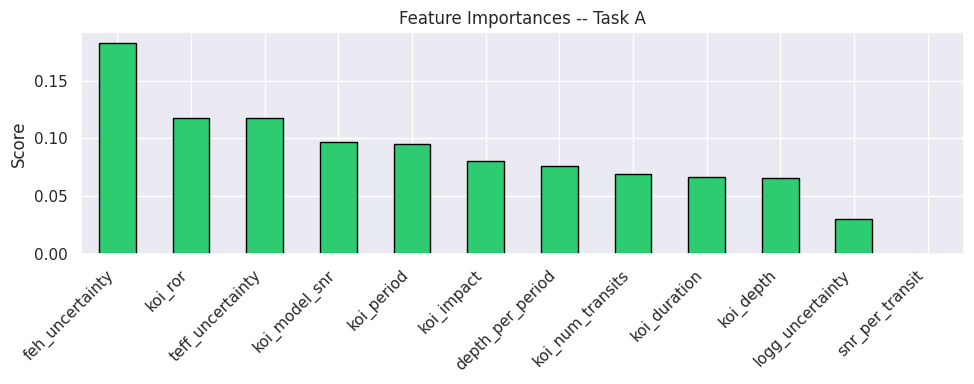

Selected 5 features for Task A:
['feh_uncertainty', 'koi_ror', 'teff_uncertainty', 'koi_model_snr', 'koi_period']


In [ ]:
print('Feature importance for Task A...')
rf_sel_A = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel_A.fit(X_train_A, y_train_A)

imp_A = pd.Series(rf_sel_A.feature_importances_, index=FEATURES_A).sort_values(ascending=False)
imp_A.plot(kind='bar', color='#2ecc71', edgecolor='black', figsize=(10, 4))
plt.title('Feature Importances -- Task A'); plt.ylabel('Score')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('feature_importance_A.png', dpi=150); plt.show()

TOP_FEATURES_A = imp_A[imp_A >= imp_A.mean()].index.tolist()
print(f'Selected {len(TOP_FEATURES_A)} features for Task A:')
print(TOP_FEATURES_A)

Feature importance for Task B...


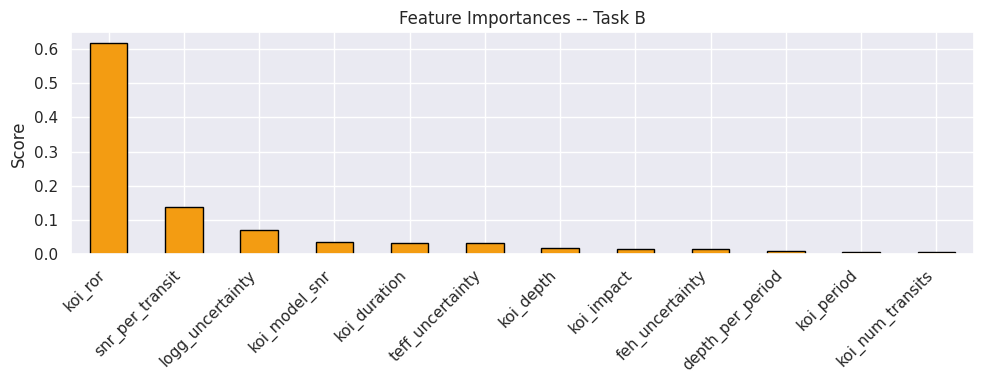

Selected 2 features for Task B:
['koi_ror', 'snr_per_transit']


In [ ]:
print('Feature importance for Task B...')
rf_sel_B = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel_B.fit(X_train_B, y_train_B)

imp_B = pd.Series(rf_sel_B.feature_importances_, index=FEATURES_B).sort_values(ascending=False)
imp_B.plot(kind='bar', color='#f39c12', edgecolor='black', figsize=(10, 4))
plt.title('Feature Importances -- Task B'); plt.ylabel('Score')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('feature_importance_B.png', dpi=150); plt.show()

TOP_FEATURES_B = imp_B[imp_B >= imp_B.mean()].index.tolist()
print(f'Selected {len(TOP_FEATURES_B)} features for Task B:')
print(TOP_FEATURES_B)

In [ ]:
X_train_A_top = X_train_A[TOP_FEATURES_A]
X_test_A_top  = X_test_A[TOP_FEATURES_A]
X_train_B_top = X_train_B[TOP_FEATURES_B]
X_test_B_top  = X_test_B[TOP_FEATURES_B]
print(f'Task A shape after selection: {X_train_A_top.shape}')
print(f'Task B shape after selection: {X_train_B_top.shape}')

Task A shape after selection: (6068, 5)
Task B shape after selection: (2195, 2)


In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Cross-Validation Results (Task A):')
print('-' * 50)
for name, clf in classifiers.items():
    cv_f1  = cross_val_score(clf, X_train_A_top, y_train_A, cv=cv, scoring='f1', n_jobs=-1)
    cv_auc = cross_val_score(clf, X_train_A_top, y_train_A, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}:')
    print(f'   F1-Score : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
    print(f'   ROC-AUC  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

Cross-Validation Results (Task A):
--------------------------------------------------
Logistic Regression:
   F1-Score : 0.7169 +/- 0.0051
   ROC-AUC  : 0.8640 +/- 0.0066
Random Forest:
   F1-Score : 0.8655 +/- 0.0081
   ROC-AUC  : 0.9597 +/- 0.0032
Gradient Boosting:
   F1-Score : 0.8717 +/- 0.0073
   ROC-AUC  : 0.9636 +/- 0.0029


In [ ]:
results_A = []
trained_classifiers = {}

for name, clf in classifiers.items():
    clf.fit(X_train_A_top, y_train_A)
    trained_classifiers[name] = clf
    result = evaluate_classifier(name, clf, X_test_A_top, y_test_A)
    results_A.append(result)


-- Logistic Regression --
   F1-Score : 0.7191
   ROC-AUC  : 0.8776
                precision    recall  f1-score   support

FALSE POSITIVE       0.82      0.90      0.86       968
     CONFIRMED       0.79      0.66      0.72       549

      accuracy                           0.81      1517
     macro avg       0.81      0.78      0.79      1517
  weighted avg       0.81      0.81      0.81      1517


-- Random Forest --
   F1-Score : 0.8788
   ROC-AUC  : 0.9675
                precision    recall  f1-score   support

FALSE POSITIVE       0.93      0.93      0.93       968
     CONFIRMED       0.87      0.89      0.88       549

      accuracy                           0.91      1517
     macro avg       0.90      0.91      0.90      1517
  weighted avg       0.91      0.91      0.91      1517


-- Gradient Boosting --
   F1-Score : 0.8858
   ROC-AUC  : 0.9707
                precision    recall  f1-score   support

FALSE POSITIVE       0.93      0.94      0.94       968
     CONFI

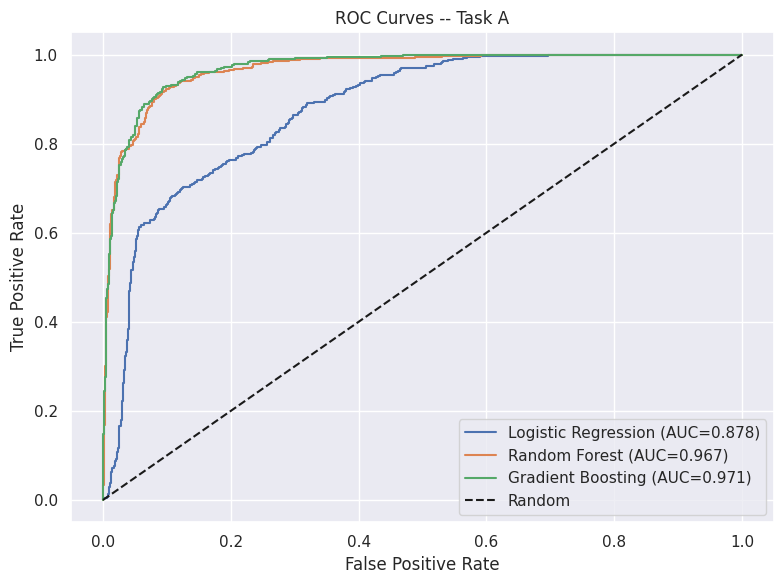

Best Classifier: Gradient Boosting
  F1-Score : 0.8858
  ROC-AUC  : 0.9707


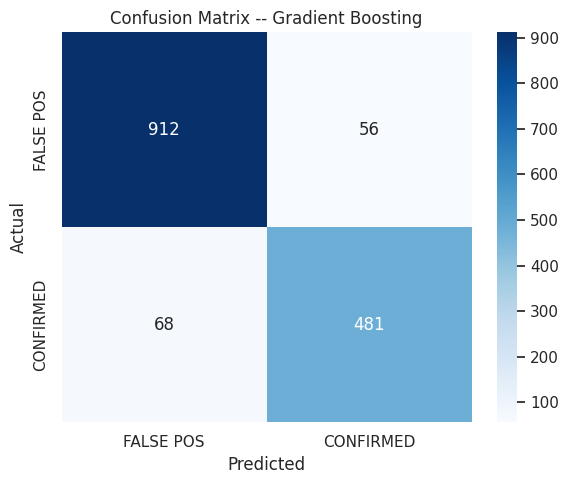

In [ ]:
plot_roc_curves(results_A, y_test_A)

best_A = max(results_A, key=lambda x: x['f1'])
print(f"Best Classifier: {best_A['name']}")
print(f"  F1-Score : {best_A['f1']:.4f}")
print(f"  ROC-AUC  : {best_A['auc']:.4f}")

plot_confusion_matrix(best_A['name'], y_test_A, best_A['y_pred'])

In [ ]:
regressors = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE)
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Cross-Validation Results (Task B):')
print('-' * 50)
for name, reg in regressors.items():
    cv_rmse = cross_val_score(reg, X_train_B_top, y_train_B, cv=cv_reg,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_mae  = cross_val_score(reg, X_train_B_top, y_train_B, cv=cv_reg,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
    print(f'{name}:')
    print(f'   RMSE : {(-cv_rmse).mean():.4f} +/- {cv_rmse.std():.4f}')
    print(f'   MAE  : {(-cv_mae).mean():.4f}  +/- {cv_mae.std():.4f}')

Cross-Validation Results (Task B):
--------------------------------------------------
Ridge:
   RMSE : 0.2966 +/- 0.0252
   MAE  : 0.2051  +/- 0.0078
Random Forest:
   RMSE : 0.2492 +/- 0.0183
   MAE  : 0.1699  +/- 0.0070
Gradient Boosting:
   RMSE : 0.2470 +/- 0.0184
   MAE  : 0.1663  +/- 0.0078


In [ ]:
results_B = []
trained_regressors = {}

for name, reg in regressors.items():
    reg.fit(X_train_B_top, y_train_B)
    trained_regressors[name] = reg
    result = evaluate_regressor(name, reg, X_test_B_top, y_test_B)
    results_B.append(result)


-- Ridge --
   RMSE : 9.6065 Earth radii
   MAE  : 1.4280 Earth radii
   R2   : -7.6169

-- Random Forest --
   RMSE : 1.2698 Earth radii
   MAE  : 0.6603 Earth radii
   R2   : 0.8495

-- Gradient Boosting --
   RMSE : 1.3337 Earth radii
   MAE  : 0.6616 Earth radii
   R2   : 0.8339


Best Regressor : Random Forest
  RMSE : 1.2698
  MAE  : 0.6603
  R2   : 0.8495


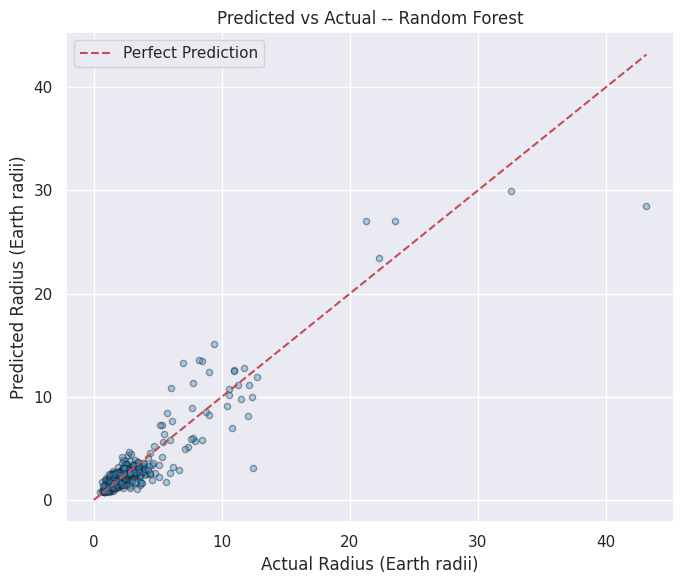

In [ ]:
best_B = min(results_B, key=lambda x: x['rmse'])
print(f"Best Regressor : {best_B['name']}")
print(f"  RMSE : {best_B['rmse']:.4f}")
print(f"  MAE  : {best_B['mae']:.4f}")
print(f"  R2   : {best_B['r2']:.4f}")

plot_pred_vs_actual(best_B['name'], best_B['y_test'], best_B['y_pred'])

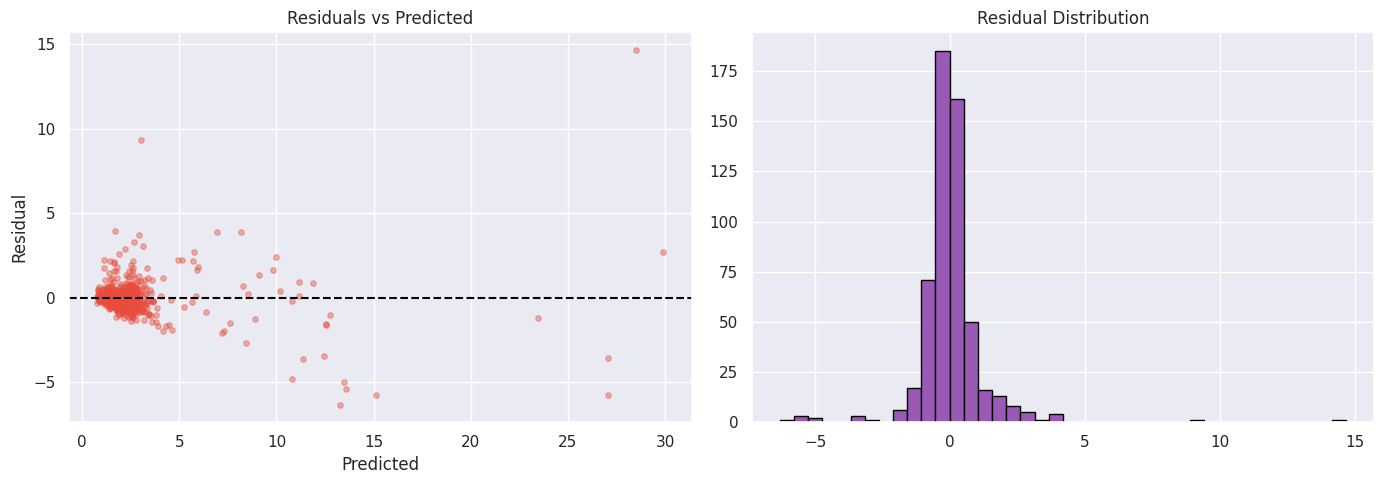

In [ ]:
residuals = best_B['y_test'] - best_B['y_pred']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(best_B['y_pred'], residuals, alpha=0.4, color='#e74c3c', s=15)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[1].hist(residuals, bins=40, color='#9b59b6', edgecolor='black')
axes[1].set_title('Residual Distribution')
plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=150); plt.show()

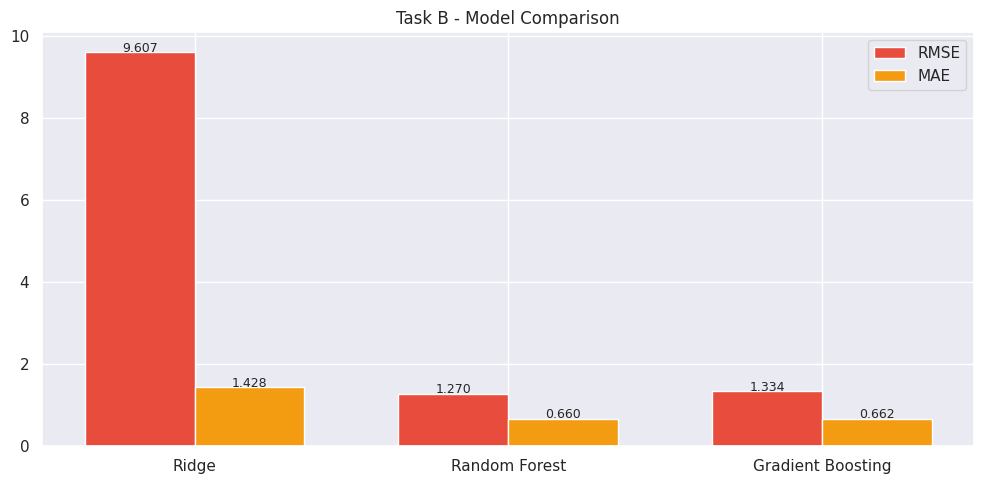

In [ ]:
names_b = [r['name'] for r in results_B]
rmses   = [r['rmse'] for r in results_B]
maes    = [r['mae']  for r in results_B]
x = np.arange(len(names_b)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, rmses, w, label='RMSE', color='#e74c3c')
ax.bar(x + w/2, maes,  w, label='MAE',  color='#f39c12')
ax.set_xticks(x); ax.set_xticklabels(names_b)
ax.set_title('Task B - Model Comparison'); ax.legend()
for i, (r, m) in enumerate(zip(rmses, maes)):
    ax.text(i - w/2, r + 0.01, f'{r:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('model_comparison_B.png', dpi=150); plt.show()

In [ ]:
joblib.dump(trained_classifiers[best_A['name']], 'best_classifier.pkl')
joblib.dump(trained_regressors[best_B['name']],  'best_regressor.pkl')
joblib.dump(TOP_FEATURES_A, 'top_features_A.pkl')
joblib.dump(TOP_FEATURES_B, 'top_features_B.pkl')

print('Models saved!')
print(f"  best_classifier.pkl -> {best_A['name']}")
print(f"  best_regressor.pkl  -> {best_B['name']}")

Models saved!
  best_classifier.pkl -> Gradient Boosting
  best_regressor.pkl  -> Random Forest


In [ ]:
from google.colab import files

to_download = [
    'best_classifier.pkl', 'best_regressor.pkl',
    'top_features_A.pkl',  'top_features_B.pkl',
    'roc_curves.png',           'model_comparison_A.png',
    'model_comparison_B.png',   'residual_analysis.png',
    'feature_importance_A.png', 'feature_importance_B.png'
]

for f in to_download:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception as e:
        print(f'Could not download {f}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_classifier.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: feature_importance_A.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: feature_importance_B.png


In [ ]:
import joblib
import pandas as pd
import numpy as np

# Load models and feature lists
clf_model = joblib.load('best_classifier.pkl')
reg_model = joblib.load('best_regressor.pkl')
feat_A    = joblib.load('top_features_A.pkl') # These are TOP_FEATURES_A
feat_B    = joblib.load('top_features_B.pkl') # These are TOP_FEATURES_B

# Load original feature lists for imputer/scaler
FEATURES_A_full = joblib.load('features_A.pkl') # These are the FEATURES_A before selection
FEATURES_B_full = joblib.load('features_B.pkl') # These are the FEATURES_B before selection

# Load preprocessors
imputer_A = joblib.load('imputer_A.pkl')
scaler_A = joblib.load('scaler_A.pkl')
imputer_B = joblib.load('imputer_B.pkl')
scaler_B = joblib.load('scaler_B.pkl')

# Simulated raw user input (as backend would receive it)
# Added median error values to allow calculation of uncertainty features
sample = {
    'koi_period': 9.49,   'koi_duration': 2.96,  'koi_depth': 615.8,
    'koi_impact': 0.15,   'koi_model_snr': 35.8, 'koi_num_transits': 142.0,
    'koi_ror': 0.022,
    'st_teff': 5455.0,    'st_logg': 4.47,         'st_met': 0.12, # Base stellar params (not used by TOP_FEATURES_A/B directly, but good to have if needed for other engineered features)
    'teff_err1': 153.0,   'teff_err2': -149.0,   # Median values from df.describe() for `teff_uncertainty` calculation
    'logg_err1': 0.074,   'logg_err2': -0.193,   # Median values from df.describe() for `logg_uncertainty` calculation
    'feh_err1': 0.22,     'feh_err2': -0.26,     # Median values from df.describe() for `feh_uncertainty` calculation
}
df_in = pd.DataFrame([sample])

# --- Feature Engineering for the sample (replicate K7TKhM2ISjdf) ---
df_sample_engineered = df_in.copy()

# Create average uncertainty features
error_pairs = {
    'teff': ('teff_err1', 'teff_err2'),
    'logg': ('logg_err1', 'logg_err2'),
    'feh':  ('feh_err1',  'feh_err2'),
}

for base, (err1, err2) in error_pairs.items():
    if err1 in df_sample_engineered.columns and err2 in df_sample_engineered.columns:
        df_sample_engineered[f'{base}_uncertainty'] = \
            (df_sample_engineered[err1].abs() + df_sample_engineered[err2].abs()) / 2
    else:
        df_sample_engineered[f'{base}_uncertainty'] = np.nan # Fallback if error columns are missing

# Add ratio: transit depth / orbital period
if 'koi_depth' in df_sample_engineered.columns and 'koi_period' in df_sample_engineered.columns:
    df_sample_engineered['depth_per_period'] = df_sample_engineered['koi_depth'] / (df_sample_engineered['koi_period'] + 1e-9)
else:
    df_sample_engineered['depth_per_period'] = np.nan

# SNR per transit
if 'koi_model_snr' in df_sample_engineered.columns and 'koi_num_transits' in df_sample_engineered.columns:
    df_sample_engineered['snr_per_transit'] = df_sample_engineered['koi_model_snr'] / (df_sample_engineered['koi_num_transits'] + 1e-9)
else:
    df_sample_engineered['snr_per_transit'] = np.nan

# Task A Prediction
# First, select the full set of features that the imputer/scaler were fitted on
input_A_for_preprocessing = df_sample_engineered[FEATURES_A_full]

# Impute missing values using the trained imputer
input_A_imputed = imputer_A.transform(input_A_for_preprocessing)
# Scale features using the trained scaler
input_A_scaled_full = scaler_A.transform(input_A_imputed)
input_A_scaled_full_df = pd.DataFrame(input_A_scaled_full, columns=FEATURES_A_full)

# Now, select only the top features that the model was trained on
input_A_final = input_A_scaled_full_df[feat_A]

pred_class = clf_model.predict(input_A_final)[0]
pred_proba = clf_model.predict_proba(input_A_final)[0]
label_map  = {1: 'CONFIRMED', 0: 'FALSE POSITIVE'}

print('--- Task A: Classification ---')
print(f'  Result     : {label_map[pred_class]}')
print(f'  Confidence : {max(pred_proba)*100:.1f}%')
print(f'  Probabilities: FALSE POSITIVE={pred_proba[0]:.3f} | CONFIRMED={pred_proba[1]:.3f}')

# Task B Prediction (only if confirmed)
print('\n--- Task B: Regression ---')
if pred_class == 1:
    # First, select the full set of features that the imputer/scaler were fitted on
    input_B_for_preprocessing = df_sample_engineered[FEATURES_B_full]

    # Impute and scale
    input_B_imputed = imputer_B.transform(input_B_for_preprocessing)
    input_B_scaled_full = scaler_B.transform(input_B_imputed)
    input_B_scaled_full_df = pd.DataFrame(input_B_scaled_full, columns=FEATURES_B_full)

    # Now, select only the top features that the model was trained on
    input_B_final = input_B_scaled_full_df[feat_B]

    pred_log_r   = reg_model.predict(input_B_final)[0]
    pred_radius  = np.expm1(pred_log_r)
    print(f'  Predicted Radius : {pred_radius:.2f} Earth radii')
else:
    print('  FALSE POSITIVE -- radius prediction skipped.')

--- Task A: Classification ---
  Result     : CONFIRMED
  Confidence : 86.6%
  Probabilities: FALSE POSITIVE=0.134 | CONFIRMED=0.866

--- Task B: Regression ---
  Predicted Radius : 2.49 Earth radii


In [ ]:
print('=' * 55)
print('     STELLAR ANALYTICS - MODEL TRAINING SUMMARY')
print('=' * 55)
print(f"\nTASK A - Classification")
print(f"  Best Model : {best_A['name']}")
print(f"  F1-Score   : {best_A['f1']:.4f}")
print(f"  ROC-AUC    : {best_A['auc']:.4f}")
print(f"  Features   : {len(TOP_FEATURES_A)}")
print(f"\nTASK B - Regression")
print(f"  Best Model : {best_B['name']}")
print(f"  RMSE       : {best_B['rmse']:.4f} Earth radii")
print(f"  MAE        : {best_B['mae']:.4f} Earth radii")
print(f"  R2         : {best_B['r2']:.4f}")
print(f"  Features   : {len(TOP_FEATURES_B)}")
print("\nNext Step: Build the Flask backend using the .pkl files!")
print('=' * 55)

     STELLAR ANALYTICS - MODEL TRAINING SUMMARY

TASK A - Classification
  Best Model : Gradient Boosting
  F1-Score   : 0.8858
  ROC-AUC    : 0.9707
  Features   : 5

TASK B - Regression
  Best Model : Random Forest
  RMSE       : 1.2698 Earth radii
  MAE        : 0.6603 Earth radii
  R2         : 0.8495
  Features   : 2

Next Step: Build the Flask backend using the .pkl files!
